In [ ]:
from sklearn.datasets import load_iris

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

##Data

In [ ]:
dt = load_iris()

In [ ]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
X, Y = dt.data, dt.target

In [ ]:
dt.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

##Model Architecture

In [ ]:
model = nn.Sequential(
    nn.Linear(4, 30),
    nn.ReLU(),
    nn.Linear(30, 10),
    nn.ReLU(),
    nn.Linear(10, 3),
    # nn.Softmax(dim=1)
)


In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [ ]:
# model(X)
# torch.argmax(model(X), dim=1)

In [ ]:
lossfn = nn.CrossEntropyLoss()
optSgd = optim.SGD(model.parameters(), lr=0.01)

##Training

In [ ]:
for _ in range(200):
    optSgd.zero_grad()
    Yp = model(X)
    loss = lossfn(Yp, Y)
    loss.backward()
    optSgd.step()

    print(loss.item())

0.19646596908569336
0.19606821238994598
0.19567202031612396
0.19527743756771088
0.19488434493541718
0.19449281692504883
0.19410282373428345
0.19371436536312103
0.1933274120092392
0.19294202327728271
0.19255799055099487
0.1921755075454712
0.19179458916187286
0.19141514599323273
0.1910371333360672
0.19066064059734344
0.1902855634689331
0.18991194665431976
0.18953979015350342
0.18916907906532288
0.18879985809326172
0.18843205273151398
0.18806569278240204
0.18770073354244232
0.18733716011047363
0.18697495758533478
0.18661421537399292
0.18625488877296448
0.18589693307876587
0.18554042279720306
0.1851852983236313
0.18483158946037292
0.184479221701622
0.18412822484970093
0.1837785840034485
0.1834302842617035
0.1830834299325943
0.18273794651031494
0.1823938488960266
0.18205101788043976
0.18170954287052155
0.1813693791627884
0.1810305416584015
0.18069306015968323
0.18035690486431122
0.18002206087112427
0.17968857288360596
0.17935635149478912
0.17902544140815735
0.17869587242603302
0.17836755514

##Inference

In [ ]:
Ynewp = model(X)

In [ ]:
sftout = torch.softmax(Ynewp, dim=1)

In [ ]:
torch.argmax(sftout, dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

##Using Batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
df = pd.DataFrame(X)

In [ ]:
df['Y'] = Y

In [ ]:
data = torch.tensor(df.to_numpy())

In [ ]:
modl = nn.Sequential(
    nn.Linear(4, 30),
    nn.ReLU(),
    nn.Linear(30, 10),
    nn.ReLU(),
    nn.Linear(10, 3),
    # nn.Softmax(dim=1)
)

In [ ]:
lossfn = nn.CrossEntropyLoss()
batchSgd = optim.SGD(modl.parameters(), lr=0.01)

In [ ]:

batches = DataLoader(data, batch_size=10, shuffle=True)

In [ ]:
modl.train()
for epoch in range(200):
    batch_loss = 0
    for i, batch in enumerate(batches):
        batch_X = batch[:, :-1].float()
        batch_Y = batch[:, -1].long()

        batchSgd.zero_grad()
        batch_Yp = modl(batch_X)
        loss = lossfn(batch_Yp, batch_Y)
        loss.backward()
        batchSgd.step()

        batch_loss = batch_loss + loss.item()
    print(f"Epoch {epoch+1}: Total Loss = {batch_loss}")

Epoch 1: Total Loss = 16.482800602912903
Epoch 2: Total Loss = 16.00441265106201
Epoch 3: Total Loss = 15.672791600227356
Epoch 4: Total Loss = 15.320427656173706
Epoch 5: Total Loss = 14.941759824752808
Epoch 6: Total Loss = 14.491555452346802
Epoch 7: Total Loss = 13.999602437019348
Epoch 8: Total Loss = 13.479791581630707
Epoch 9: Total Loss = 12.910965383052826
Epoch 10: Total Loss = 12.338803827762604
Epoch 11: Total Loss = 11.757489800453186
Epoch 12: Total Loss = 11.193045675754547
Epoch 13: Total Loss = 10.657582640647888
Epoch 14: Total Loss = 10.155009329319
Epoch 15: Total Loss = 9.667089462280273
Epoch 16: Total Loss = 9.218650847673416
Epoch 17: Total Loss = 8.847969323396683
Epoch 18: Total Loss = 8.497196435928345
Epoch 19: Total Loss = 8.193712443113327
Epoch 20: Total Loss = 7.925388395786285
Epoch 21: Total Loss = 7.7289526760578156
Epoch 22: Total Loss = 7.493492960929871
Epoch 23: Total Loss = 7.353015959262848
Epoch 24: Total Loss = 7.196557998657227
Epoch 25: Tota

In [ ]:
X = torch.FloatTensor(X)

In [ ]:
soft = torch.softmax(modl(X), dim=1)

In [ ]:
torch.argmax(soft, dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2,
        2, 2, 2, 2, 2, 2])

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dt = load_digits(n_class=3)

In [ ]:
images = dt.images

In [ ]:
Y = dt.target

In [ ]:
images[-2]

array([[ 0.,  0., 15., 13.,  1.,  0.,  0.,  0.],
       [ 0.,  0., 14., 14.,  4.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  6., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 11., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  1., 16.,  8.,  6.,  5.,  0.],
       [ 0.,  0., 13., 16., 16., 16., 14.,  0.],
       [ 0.,  0., 10., 13., 10.,  6.,  2.,  0.]])

In [ ]:
Y[-2]

np.int64(2)

In [ ]:
images[0].reshape(1, 64)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
images.shape

(537, 8, 8)

In [ ]:
X = images.reshape(-1,64)

In [ ]:
X.shape

(537, 64)

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)
print(X)
print(Y)

tensor([[[[ 0.,  0.,  5.,  ...,  1.,  0.,  0.],
          [ 0.,  0., 13.,  ..., 15.,  5.,  0.],
          [ 0.,  3., 15.,  ..., 11.,  8.,  0.],
          ...,
          [ 0.,  4., 11.,  ..., 12.,  7.,  0.],
          [ 0.,  2., 14.,  ..., 12.,  0.,  0.],
          [ 0.,  0.,  6.,  ...,  0.,  0.,  0.]]],


        [[[ 0.,  0.,  0.,  ...,  5.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  9.,  0.,  0.],
          [ 0.,  0.,  3.,  ...,  6.,  0.,  0.],
          ...,
          [ 0.,  0.,  1.,  ...,  6.,  0.,  0.],
          [ 0.,  0.,  1.,  ...,  6.,  0.,  0.],
          [ 0.,  0.,  0.,  ..., 10.,  0.,  0.]]],


        [[[ 0.,  0.,  0.,  ..., 12.,  0.,  0.],
          [ 0.,  0.,  3.,  ..., 14.,  0.,  0.],
          [ 0.,  0.,  8.,  ..., 16.,  0.,  0.],
          ...,
          [ 0.,  9., 16.,  ...,  0.,  0.,  0.],
          [ 0.,  3., 13.,  ..., 11.,  5.,  0.],
          [ 0.,  0.,  0.,  ..., 16.,  9.,  0.]]],


        ...,


        [[[ 0.,  1., 10.,  ...,  0.,  0.,  0.],
          [ 0., 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

In [ ]:
# model(X)
# nn.NLLLoss()

In [ ]:
lossfn = nn.CrossEntropyLoss()

In [ ]:
opt = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
for _ in range(30):
    opt.zero_grad()
    Yp = model(X)
    loss = lossfn(Yp, Y)
    loss.backward()
    opt.step()
    print(loss)

tensor(1.3597, grad_fn=<NllLossBackward0>)
tensor(1.7273, grad_fn=<NllLossBackward0>)
tensor(0.8201, grad_fn=<NllLossBackward0>)
tensor(0.2593, grad_fn=<NllLossBackward0>)
tensor(0.2681, grad_fn=<NllLossBackward0>)
tensor(0.2654, grad_fn=<NllLossBackward0>)
tensor(0.2000, grad_fn=<NllLossBackward0>)
tensor(0.1621, grad_fn=<NllLossBackward0>)
tensor(0.1352, grad_fn=<NllLossBackward0>)
tensor(0.0976, grad_fn=<NllLossBackward0>)
tensor(0.0630, grad_fn=<NllLossBackward0>)
tensor(0.0410, grad_fn=<NllLossBackward0>)
tensor(0.0307, grad_fn=<NllLossBackward0>)
tensor(0.0270, grad_fn=<NllLossBackward0>)
tensor(0.0266, grad_fn=<NllLossBackward0>)
tensor(0.0271, grad_fn=<NllLossBackward0>)
tensor(0.0272, grad_fn=<NllLossBackward0>)
tensor(0.0263, grad_fn=<NllLossBackward0>)
tensor(0.0246, grad_fn=<NllLossBackward0>)
tensor(0.0224, grad_fn=<NllLossBackward0>)
tensor(0.0200, grad_fn=<NllLossBackward0>)
tensor(0.0177, grad_fn=<NllLossBackward0>)
tensor(0.0154, grad_fn=<NllLossBackward0>)
tensor(0.01

In [ ]:
model(X)

tensor([[  5.4248,  -4.5354,  -3.4751],
        [ -8.4273,   7.8224,  -6.0488],
        [ -7.2466,  -1.3686,   3.3461],
        ...,
        [-13.9550,  -2.3222,   8.4088],
        [ -8.6751,  -1.9981,   5.8447],
        [  5.8529,  -4.5774,  -3.9356]], grad_fn=<AddmmBackward0>)

In [ ]:
# pip install opencv-python --q

In [ ]:
import cv2

In [ ]:
ar = cv2.imread('one-1.webp')

In [ ]:
ar.shape

(1280, 1280, 3)

In [ ]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY)

In [ ]:
rszar = cv2.resize(grar, (8, 8))

In [ ]:
far = rszar.reshape(1, 64)
far

array([[  0,   0, 135, 135, 135, 135,   0,   0,   0, 135, 135, 135, 135,
        135, 135,   0, 135, 135, 135, 135, 255, 135, 135, 135, 135, 135,
        135, 135, 255, 135, 135, 135, 135, 135, 135, 135, 255, 135, 135,
        135, 135, 135, 135, 135, 255, 135, 135, 135,   0, 135, 135, 135,
        135, 135, 135,   0,   0,   0, 135, 135, 135, 135,   0,   0]],
      dtype=uint8)

In [ ]:
fimg = torch.FloatTensor(far)

In [ ]:
  model(fimg)

tensor([[ 18.0301,   0.9806, -32.9785]], grad_fn=<AddmmBackward0>)

In [ ]:
sfx = torch.softmax(model(fimg), dim=1)

In [ ]:
torch.argmax(sfx, dim=1)

tensor([0])

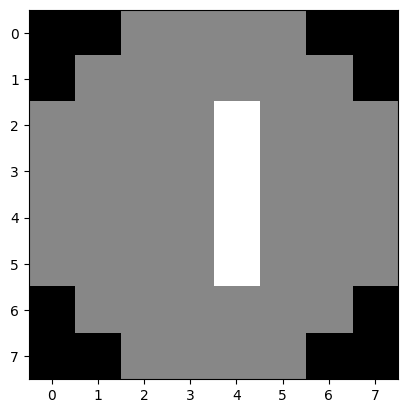

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(rszar, cmap='gray')
plt.show()

In [ ]:
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

model(fimg)

tensor([[ 18.0301,   0.9806, -32.9785]], grad_fn=<AddmmBackward0>)

In [ ]:
sfx = torch.softmax(model(fimg), dim=1)

In [ ]:
torch.argmax(sfx, dim=1)

tensor([0])

##Convolution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ar = np.array([3,5,6,2,1,5])

In [ ]:
np.convolve(ar, [1,2,3]) # (3,2,1)

array([ 3, 11, 25, 29, 23, 13, 13, 15])

##Covolution On the Images from load_digits

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dt = load_digits(n_class=3)

In [ ]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
dt.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
dt.images.shape

(537, 8, 8)

In [ ]:
X = dt.images
Y = dt.target

In [ ]:
X = X.reshape(537,1,8,8)

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [ ]:
X.shape

torch.Size([537, 1, 8, 8])

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

In [ ]:
loss = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=0.001)

In [ ]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = model(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.3312598764896393
0.051759202033281326
0.011601535603404045
0.003647895297035575
0.001553367474116385
0.0008963762666098773
0.0005995199899189174
0.0004247087344992906
0.00032411463325843215
0.00025986379478126764


In [ ]:
newx = X[112].reshape(1,1,8,8)

In [ ]:
newx.shape

torch.Size([1, 1, 8, 8])

In [ ]:
Yp = model(newx)

In [ ]:
Yp

tensor([[ 0.0247, 10.8868,  0.8146]], grad_fn=<AddmmBackward0>)

In [ ]:
sx = torch.softmax(Yp, dim=1)

In [ ]:
torch.argmax(sx, dim=1)

tensor([1])

##Using Batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
import pandas as pd
df = pd.DataFrame(X.reshape(X.shape[0], -1))

In [ ]:
df['Y'] = Y

In [ ]:
data = torch.tensor(df.to_numpy())

In [ ]:
modl = nn.Sequential(
    nn.Linear(64, 30),
    nn.ReLU(),
    nn.Linear(30, 10),
    nn.ReLU(),
    nn.Linear(10, 3),
    # nn.Softmax(dim=1)
)

In [ ]:
lossfn = nn.CrossEntropyLoss()
batchSgd = optim.SGD(modl.parameters(), lr=0.01)

In [ ]:
batches = DataLoader(data, batch_size=10, shuffle=True)

In [ ]:
modl.train()
c=0
for epoch in range(100):
    c=c+1
    epoch_loss = 0.0
    for i, batch in enumerate(batches):
        batch_X = batch[:, :-1].float()
        batch_Y = batch[:, -1].long()

        batchSgd.zero_grad()
        batch_Yp = modl(batch_X)
        loss = lossfn(batch_Yp, batch_Y)
        loss.backward()
        batchSgd.step()

        epoch_loss += loss.item()

    if c%10==0:
      print(epoch_loss)

0.002493906293011605
0.002472974149441143
0.002387086305589037
0.002382019182050499
0.0022820945162038697
0.0022432688261915246
0.0021882417408960464
0.0021468082881312966
0.002166115129476509
0.002059303264147161


In [ ]:
X = torch.FloatTensor(X)

In [ ]:
torch.argmax(sx, dim=1)

tensor([1])

In [ ]:
soft = torch.softmax(modl(X.reshape(X.shape[0], -1)), dim=1)

In [ ]:
torch.argmax(soft, dim=1)

tensor([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2,
        2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2,
        0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1,
        0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2,
        0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2,
        0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0,
        1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1,
        1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2,
        2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2,
        1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2,
        0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1,
        1, 1, 1, 0, 1, 2, 2, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0,
        1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1,

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dt = load_digits(n_class=3)

In [ ]:
images = dt.images

In [ ]:
Y = dt.target

In [ ]:
Y[-2]

np.int64(2)

In [ ]:
images[0].reshape(1, 64)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
images.shape

(537, 8, 8)

In [ ]:
X = images.reshape(-1,64)

In [ ]:
X.shape

(537, 64)

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)
print(X)
print(Y)

tensor([[ 0.,  0.,  5.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ..., 10.,  0.,  0.],
        [ 0.,  0.,  0.,  ..., 16.,  9.,  0.],
        ...,
        [ 0.,  1., 10.,  ..., 10.,  9.,  0.],
        [ 0.,  0., 15.,  ...,  6.,  2.,  0.],
        [ 0.,  0.,  6.,  ...,  6.,  0.,  0.]])
tensor([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2,
        2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2,
        0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1,
        0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2,
        0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2,
        0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0,
        1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1,
        1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2,
        2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2,

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

In [9]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

In [10]:
lossfn = nn.CrossEntropyLoss()

In [11]:
opt = optim.Adam(model.parameters(), lr=0.01)

In [12]:
for _ in range(30):
    opt.zero_grad()
    Yp = model(X)
    loss = lossfn(Yp, Y)
    loss.backward()
    opt.step()
    print(loss)

NameError: name 'X' is not defined

In [ ]:
model(X)

In [ ]:
import cv2

In [14]:
ar = cv2.imread('0.webp')
ar.shape

(474, 474, 3)

In [15]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY)

In [16]:
rszar = cv2.resize(grar, (8, 8))

In [17]:
far = rszar.reshape(1, 64)
far

array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 223, 144, 148,
        131, 255, 255, 255, 255, 191, 255, 255, 241, 255, 255, 255, 255,
         90, 254, 255, 224, 254, 255, 255, 255, 119, 255, 255, 181, 255,
        255, 255, 255, 120, 254, 255, 180, 253, 255, 253, 249, 176, 235,
        140, 235, 244, 248, 248, 237, 218, 210, 217, 227, 241, 249]],
      dtype=uint8)

In [18]:
fimg = torch.FloatTensor(far)
model(fimg)

tensor([[ 38.0983, -20.8980, -23.3914]], grad_fn=<AddmmBackward0>)

In [20]:
sfx = torch.softmax(model(fimg), dim=1)

In [25]:
torch.argmax(sfx, dim=1)

tensor([0])

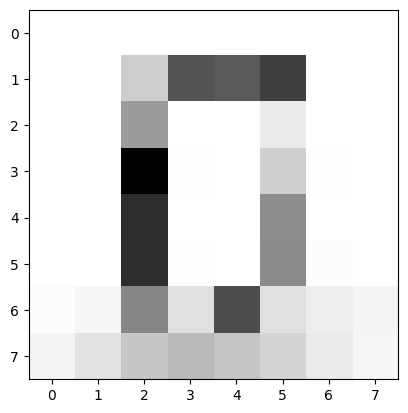

In [22]:
import matplotlib.pyplot as plt
plt.imshow(rszar, cmap='gray')
plt.show()

In [23]:
torch.argmax(sfx, dim=1)

tensor([0])

##Class based Model

In [ ]:
class MyNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
    self.maxm = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(64*2*2, 128)
    self.linear2 = nn.Linear(128, 3)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxm(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.maxm(x)
    x = self.flatten(x)
    x = self.linear1(x)
    x = self.relu(x)
    x = self.linear2(x)
    return x

In [ ]:
mod = MyNet()

In [ ]:
mod(X.reshape(-1, 1, 8, 8))

tensor([[ 0.6781, -0.1201,  1.4398],
        [ 0.7302, -0.1779,  1.3223],
        [ 0.3190, -0.2623,  1.3302],
        ...,
        [ 0.7333, -0.2494,  1.5615],
        [ 0.7537, -0.1409,  1.3984],
        [ 0.9271, -0.1287,  1.8877]], grad_fn=<AddmmBackward0>)

In [ ]:
import torch.optim as optim
loss = nn.CrossEntropyLoss()
opt = optim.Adam(mod.parameters(), lr=0.001)

In [ ]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    # Reshape X to (batch_size, channels, height, width) for Conv2d layer
    yp = mod(X.reshape(-1, 1, 8, 8))
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.30232757329940796
0.06238999962806702
0.018547993153333664
0.007806360721588135
0.0038176430389285088
0.002141999313607812
0.0014279179740697145
0.0009966277284547687
0.0007441199850291014
0.0005750201526097953
